# Site projection, July 2026

This notebook projects the locations of our four sites on Flask using satellite derived velocities. 

It uses as a starting point the locations of four sites on flask mapped in satellite imagery from March 2026 


Main flask sites mapped from /Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/remote sensing/worldview/jan26_FG/apr26_FG/fridge_1408_jkingslake/ortho/WV03_20260302130239_10400100B6944000_26MAR02130239-P1BS-510279542050_01_P001_u16ns3031.tif

Plateau sites mapped from /Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/remote sensing/worldview/jan26_FG/apr26_FG/fridge_1408_jkingslake/ortho/WV03_20260213132852_10400100B3259A00_26FEB13132852-P1BS-510249685060_01_P001_u16ns3031.tif

In [56]:
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray
import numpy as np
import pandas as pd

## Read site locations 


In [4]:
gdf = gpd.read_file("/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/fieldwork/recce_planning_2026/sites_mapped_20260302.shp")
gdf

,Site,lat,lon,geometry
0,Rock,-65.801145,-62.672029,POINT (-62.67209 -65.80119)
1,Flask 1,-65.793357,-62.676819,POINT (-62.67657 -65.79349)
2,Flask 2,-65.783029,-62.688740,POINT (-62.68716 -65.78332)
3,Flask 3,-65.784763,-62.660484,POINT (-62.65839 -65.78491)
4,Flask 4,-65.776231,-62.661684,POINT (-62.65953 -65.77621)


In [5]:
gdf.to_crs("EPSG:3031", inplace=True)
gdf

,Site,lat,lon,geometry
0,Rock,-65.801145,-62.672029,POINT (-2369766.883 1224590.358)
1,Flask 1,-65.793357,-62.676819,POINT (-2370639.609 1224806.115)
2,Flask 2,-65.783029,-62.688740,POINT (-2371890.736 1224897.428)
3,Flask 3,-65.784763,-62.660484,POINT (-2371115.384 1226005.589)
4,Flask 4,-65.776231,-62.661684,POINT (-2372016.287 1226411.186)


In [6]:
gdf.set_index('Site', inplace=True)
def point(site):
    return (gdf.loc[site].geometry.x, gdf.loc[site].geometry.y)

## Load in multi-year average velocities

In [7]:
V = rioxarray.open_rasterio('/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/remote sensing/velocities/multiyear/20141125_20250805/V_median_20141125_20250805_200m_timefiltered.tif').load()
U = rioxarray.open_rasterio('/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/remote sensing/velocities/multiyear/20141125_20250805/U_median_20141125_20250805_200m_timefiltered.tif').load()
S = rioxarray.open_rasterio('/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/remote sensing/velocities/multiyear/20141125_20250805/S_median_20141125_20250805_200m_timefiltered.tif').load()

Text(0.5, 1.0, 'speed with mapped locations')

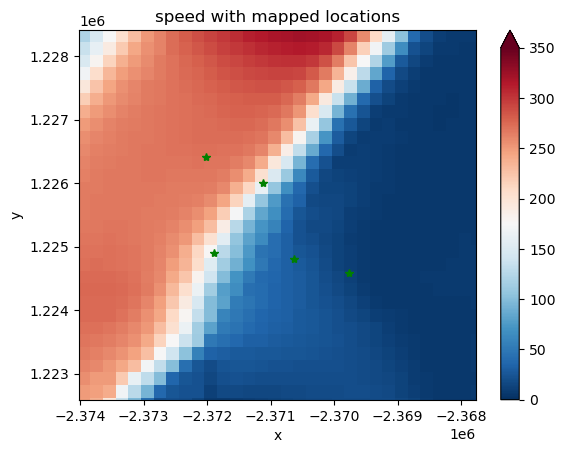

In [8]:
L = 2000
max_S = 350

xs = [point(site)[0] for site in gdf.index]
ys = [point(site)[1] for site in gdf.index]

S.squeeze().plot.imshow(vmax=max_S, vmin=0, cmap='RdBu_r', xlim=[min(xs)-L, max(xs)+L], ylim=[min(ys)-L, max(ys)+L])
for site in gdf.index:
    p = point(site)
    plt.plot(p[0], p[1], 'g*')

plt.title('speed with mapped locations')

## interpolate the U and V at the sites

In [9]:
U_sites = [U.interp(x=[point(site)[0]], y=[point(site)[1]], method='nearest').item() for site in gdf.index]
V_sites = [V.interp(x=[point(site)[0]], y=[point(site)[1]], method='nearest').item() for site in gdf.index]
V_sites

[4.872355937957764,
 22.09844398498535,
 149.367919921875,
 125.32212829589844,
 197.04055786132812]

## add U and V values to the gdf

In [15]:
gdf['U'] = U_sites
gdf['V'] = V_sites
gdf

,lat,lon,geometry,U,V,newX,newY
Site,,,,,,,
Rock,-65.801145,-62.672029,POINT (-2369766.883 1224590.358),-3.655704,4.872356,-2.369769e+06,1.224594e+06
Flask 1,-65.793357,-62.676819,POINT (-2370639.609 1224806.115),-6.052073,22.098444,-2.370644e+06,1.224821e+06
Flask 2,-65.783029,-62.688740,POINT (-2371890.736 1224897.428),87.362900,149.367920,-2.371832e+06,1.224997e+06
Flask 3,-65.784763,-62.660484,POINT (-2371115.384 1226005.589),87.249817,125.322128,-2.371057e+06,1.226089e+06
Flask 4,-65.776231,-62.661684,POINT (-2372016.287 1226411.186),181.110031,197.040558,-2.371895e+06,1.226543e+06


## compute time interval

In [16]:
dt_days = np.datetime64('2026-11-01') - np.datetime64('2026-03-02') 
dt = dt_days / np.timedelta64(1, 'D') / 365.25   # units: years
dt

np.float64(0.6680355920602327)

## compute new locations


In [17]:
newX = [point(site)[0] + gdf.loc[site, 'U'] * dt for site in gdf.index]
gdf['newX'] = newX
newY = [point(site)[1] + gdf.loc[site, 'V'] * dt for site in gdf.index]
gdf['newY'] = newY
gdf

,lat,lon,geometry,U,V,newX,newY
Site,,,,,,,
Rock,-65.801145,-62.672029,POINT (-2369766.883 1224590.358),-3.655704,4.872356,-2.369769e+06,1.224594e+06
Flask 1,-65.793357,-62.676819,POINT (-2370639.609 1224806.115),-6.052073,22.098444,-2.370644e+06,1.224821e+06
Flask 2,-65.783029,-62.688740,POINT (-2371890.736 1224897.428),87.362900,149.367920,-2.371832e+06,1.224997e+06
Flask 3,-65.784763,-62.660484,POINT (-2371115.384 1226005.589),87.249817,125.322128,-2.371057e+06,1.226089e+06
Flask 4,-65.776231,-62.661684,POINT (-2372016.287 1226411.186),181.110031,197.040558,-2.371895e+06,1.226543e+06


## Create a new gdf with the new locations

In [18]:
# create new gdf with newX and newY as geometry
gdf_new = gdf.copy()
# drop lat and lon
#gdf_new.drop(columns=['Lat', 'Long'], inplace=True)
gdf_new['geometry'] = gpd.points_from_xy(gdf_new['newX'], gdf_new['newY'])
gdf_new

,lat,lon,geometry,U,V,newX,newY
Site,,,,,,,
Rock,-65.801145,-62.672029,POINT (-2369769.326 1224593.613),-3.655704,4.872356,-2.369769e+06,1.224594e+06
Flask 1,-65.793357,-62.676819,POINT (-2370643.652 1224820.878),-6.052073,22.098444,-2.370644e+06,1.224821e+06
Flask 2,-65.783029,-62.688740,POINT (-2371832.374 1224997.211),87.362900,149.367920,-2.371832e+06,1.224997e+06
Flask 3,-65.784763,-62.660484,POINT (-2371057.098 1226089.309),87.249817,125.322128,-2.371057e+06,1.226089e+06
Flask 4,-65.776231,-62.661684,POINT (-2371895.299 1226542.816),181.110031,197.040558,-2.371895e+06,1.226543e+06


In [19]:
# gdf_new.to_file("/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/fieldwork/recce_planning_2026/projected_for_Nov2026.shp")

In [20]:
distance_moved = np.hypot(gdf_new['U'], gdf_new['V'])*dt
distance_moved

Site
Rock         4.069210
Flask 1     15.306164
Flask 2    115.597285
Flask 3    102.010952
Flask 4    178.786375
dtype: float64

In [78]:
gdf_for_shp = gdf_new.copy()
gdf_for_shp.to_crs(epsg=4326, inplace=True)
gdf_for_shp.drop(columns=['lat', 'lon','newX', 'newY', 'U', 'V'],  inplace=True)

gdf_for_shp['description'] = ['Rock site (GNSS)',
                                  'Flask 1 (AWS, GNSS, 2 time-lapse cameras)', 
                                  'Flask 2 (GNSS, ApRES,  trillium seismometer)', 
                                  'Flask 3 (GNSS)', 
                                  'Flask 4 (GNSS)',]
gdf_for_shp

,geometry,description
Site,,
Rock,POINT (-62.67205 -65.80116),Rock site (GNSS)
Flask 1,POINT (-62.67633 -65.79339),"Flask 1 (AWS, GNSS, 2 time-lapse cameras)"
Flask 2,POINT (-62.68468 -65.78337),"Flask 2 (GNSS, ApRES, trillium seismometer)"
Flask 3,POINT (-62.65622 -65.78502),Flask 3 (GNSS)
Flask 4,POINT (-62.65583 -65.77663),Flask 4 (GNSS)


## add plateau site

In [79]:
plat = gpd.read_file("/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/fieldwork/recce_planning_2026/plateua_mapped_feb26.shp")
# 
plat.rename(columns={'id': 'Site'}, inplace=True)
plat.loc[0, 'Site'] = 'Plateau 1'
plat.loc[1, 'Site'] = 'Plateau 2'
plat.set_index('Site', inplace=True)
plat['description'] = ['Plateau site 1 (AWS, GNSS, ApRES)', 'Plateau site 2 (datacude seimometer)']

gdf_for_shp = pd.concat([gdf_for_shp, plat], axis=0)


gdf_for_shp

,geometry,description
Site,,
Rock,POINT (-62.67205 -65.80116),Rock site (GNSS)
Flask 1,POINT (-62.67633 -65.79339),"Flask 1 (AWS, GNSS, 2 time-lapse cameras)"
Flask 2,POINT (-62.68468 -65.78337),"Flask 2 (GNSS, ApRES, trillium seismometer)"
Flask 3,POINT (-62.65622 -65.78502),Flask 3 (GNSS)
Flask 4,POINT (-62.65583 -65.77663),Flask 4 (GNSS)
Plateau 1,POINT (-62.6873 -65.86762),"Plateau site 1 (AWS, GNSS, ApRES)"
Plateau 2,POINT (-62.68467 -65.8675),Plateau site 2 (datacude seimometer)


In [80]:
gdf_for_shp.to_file('/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/fieldwork/recce_planning_2026/site_locations_for_2026_planning.shp')
gdf_for_shp

/var/folders/kl/3mt9f4qs1559xwy3mr60s7980000gp/T/ipykernel_139/61904779.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_for_shp.to_file('/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/fieldwork/recce_planning_2026/site_locations_for_2026_planning.shp')
/Users/jkingslake/.local/share/mamba/envs/pdem_tools/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'description' to 'descriptio'
  ogr_write(


,geometry,description
Site,,
Rock,POINT (-62.67205 -65.80116),Rock site (GNSS)
Flask 1,POINT (-62.67633 -65.79339),"Flask 1 (AWS, GNSS, 2 time-lapse cameras)"
Flask 2,POINT (-62.68468 -65.78337),"Flask 2 (GNSS, ApRES, trillium seismometer)"
Flask 3,POINT (-62.65622 -65.78502),Flask 3 (GNSS)
Flask 4,POINT (-62.65583 -65.77663),Flask 4 (GNSS)
Plateau 1,POINT (-62.6873 -65.86762),"Plateau site 1 (AWS, GNSS, ApRES)"
Plateau 2,POINT (-62.68467 -65.8675),Plateau site 2 (datacude seimometer)


In [81]:
gdf_for_csv = gdf_for_shp.copy()
gdf_for_csv['lat'] = gdf_for_csv.geometry.y
gdf_for_csv['lon'] = gdf_for_csv.geometry.x
gdf_for_csv.drop(columns=['geometry'], inplace=True)
gdf_for_csv.to_csv("/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/fieldwork/recce_planning_2026/site_locations_for_2026_planning.csv")
gdf_for_csv

,description,lat,lon
Site,,,
Rock,Rock site (GNSS),-65.801161,-62.672048
Flask 1,"Flask 1 (AWS, GNSS, 2 time-lapse cameras)",-65.793395,-62.676331
Flask 2,"Flask 2 (GNSS, ApRES, trillium seismometer)",-65.783372,-62.684680
Flask 3,Flask 3 (GNSS),-65.785024,-62.656216
Flask 4,Flask 4 (GNSS),-65.776625,-62.655834
Plateau 1,"Plateau site 1 (AWS, GNSS, ApRES)",-65.867617,-62.687301
Plateau 2,Plateau site 2 (datacude seimometer),-65.867498,-62.684672
